In [1]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from sklearn import linear_model    # Herramientas de modelos lineales
from sklearn.metrics import mean_squared_error, r2_score    # Medidas de desempeño
from sklearn.preprocessing import PolynomialFeatures    # Herramientas de polinomios

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.datasets import make_regression
from formulaic import Formula

import matplotlib.pyplot as plt

import formulaic

In [2]:
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Si necesitan instalar algún paquete
#pip install gapminder
#!pip install formulaic

# Parte 2 - RidgeCV Y Grid search

Veamos como usar algunos algunas funciones específicas para encontrar el hiperparámetro alpha óptimo por validación cruzada.

In [4]:
# Comenzamos con un conjunto de datos sintéticos
from scipy import stats

In [5]:
def generar_datos(n=1000, amin=0, amax=20, bmin=5, bmax=20, seed=2906):
    np.random.seed(seed)
    brange = bmax - bmin
    a = stats.uniform.rvs(size=n, loc=amin, scale=amax - amin)
    b = stats.norm.rvs(size=n, loc=bmin + brange / 2, scale=brange / 8)
    eps = stats.norm.rvs(size=n, loc=0, scale=4)
    y = 1 + 3 * a - 2 * b + 1.5 * a * b - 0.8 * a**2 + 0.6 * b**2 + eps
    return pd.DataFrame({"a": a, "b": b}), pd.Series(y)


X, y = generar_datos()

In [6]:
X

,a,b
0,8.734133,15.394511
1,13.034632,12.525557
2,17.034105,10.551190
3,10.817888,15.382497
4,9.217678,13.748394
...,...,...
995,8.671706,12.553847
996,6.947835,8.640205
997,4.878641,14.271576
998,11.313032,16.268229


In [7]:
y

0      280.324677
1      216.688679
2      131.789786
3      303.421562
4      235.852460
          ...    
995    195.343680
996    102.264704
997    200.028047
998    333.430498
999    110.685708
Length: 1000, dtype: float64

In [8]:
# Graficamos la variable respuesta en funcion de las explicativas, en dos gráficos separados

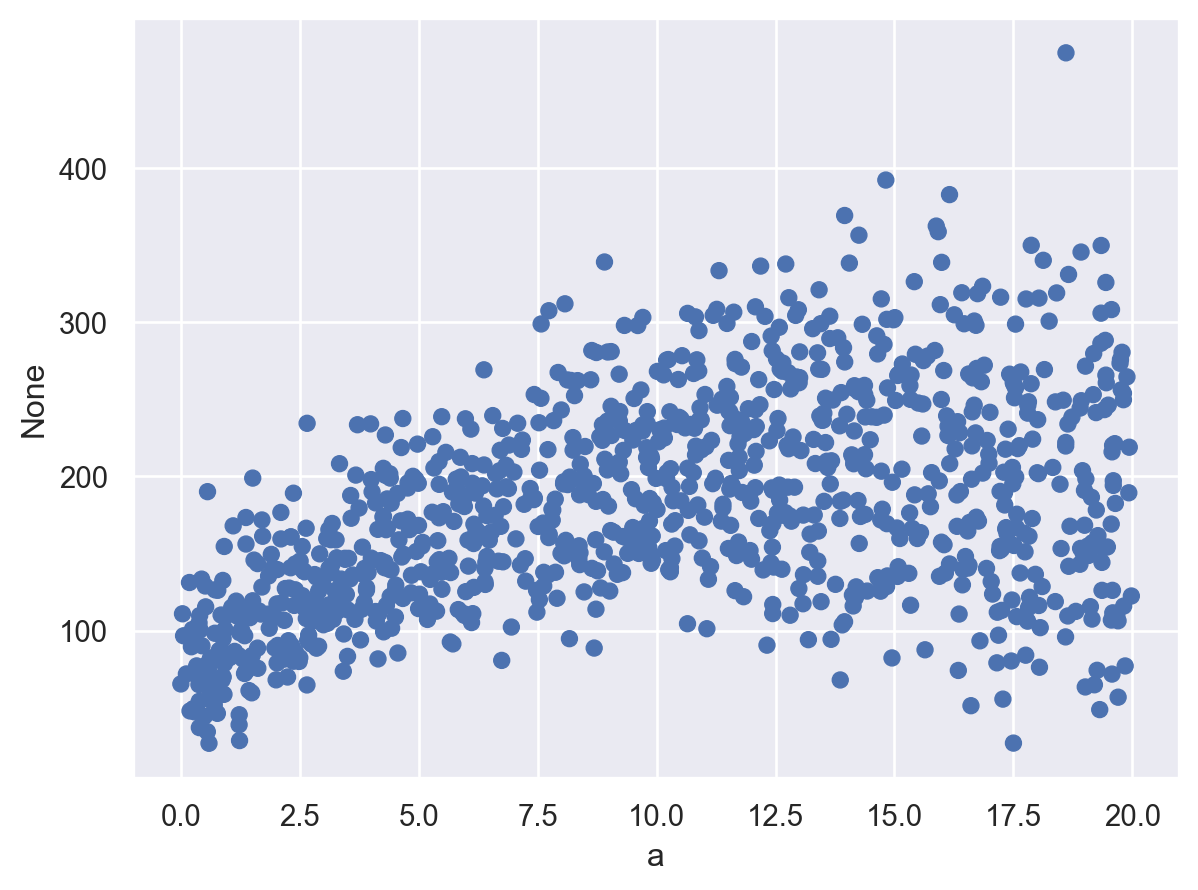

In [9]:
(
    so.Plot(x = X.a, y = y)
    .add(so.Dot())
)

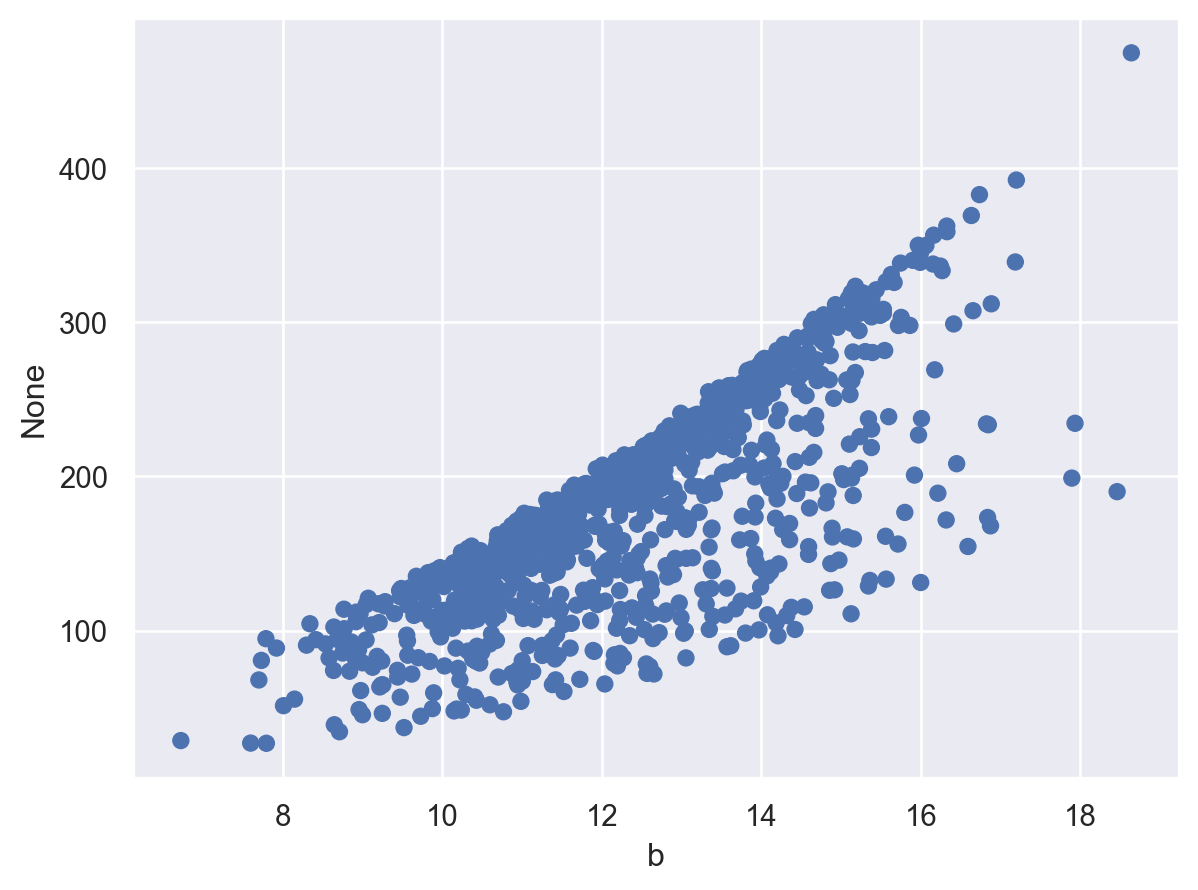

In [10]:
(
    so.Plot(x = X.b, y = y)
    .add(so.Dot())
)

In [11]:
# Probamos primero un modelo lineal
test_split = 0.96  # (tomamos pocos datos de entrenamiento para aumentar el problema de colinealidad)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state = 42)

In [12]:
modeloLineal1 = linear_model.LinearRegression()
modeloLineal1.fit(X_train, y_train)

LinearRegression()

In [13]:
# Guardamos los coeficientes en forma prolija
beta1 = pd.Series(modeloLineal1.coef_, index=X_train.columns)
beta1["intercept"] = modeloLineal1.intercept_
beta1

a              7.485950
b             23.592240
intercept   -186.412212
dtype: float64

In [15]:
# Calculando el ECM en entrenamiento y testeo

# ECM train
y_pred = modeloLineal1.predict(X_train)
ecm = mean_squared_error(y_train, y_pred)
print('Raiz cuadarada del ECM en entrenamiento: ', np.sqrt(ecm))

# ECM test
y_pred = modeloLineal1.predict(X_test)
ecm = mean_squared_error(y_test, y_pred)
print('Raiz cuadarada del ECM en testeo: ', np.sqrt(ecm))

# R2 test
r2 = r2_score(y_test, y_pred)
print(f"R cuadrado: {r2:.5f}")

Raiz cuadarada del ECM en entrenamiento:  28.465065301299337
Raiz cuadarada del ECM en testeo:  32.83477455378334
R cuadrado: 0.77199


## Análisis de residuos

Llamamos residuo al error en la predicción, es decir la diferencia entre el valor real y el valor predicho $(y - y_{\text{pred}})$.

Queremos ver si hay estructura en los residuos o parecen aleatorios.

Si hay estructura significa que hay alguna relación que no estamos teniendo en cuenta en el modelo.



In [16]:
# Ponemos todo en un solo DataFrame
# Podemos usar también pd.concat, pero tenemos que tener cuidado con los índices!
df_test = X_test.copy()
df_test["y"] = y_test
df_test["y_pred"] = y_pred
df_test["resid"] = df_test["y"] - df_test["y_pred"]
df_test.head()

,a,b,y,y_pred,resid
521,17.800631,13.459526,241.010740,264.382794,-23.372054
737,4.259771,13.761681,174.131496,170.145107,3.986389
740,0.846224,13.544226,110.064881,139.461200,-29.396320
660,9.526693,14.045863,250.502097,216.277517,34.224579
411,13.007541,14.005090,264.026107,241.373042,22.653065


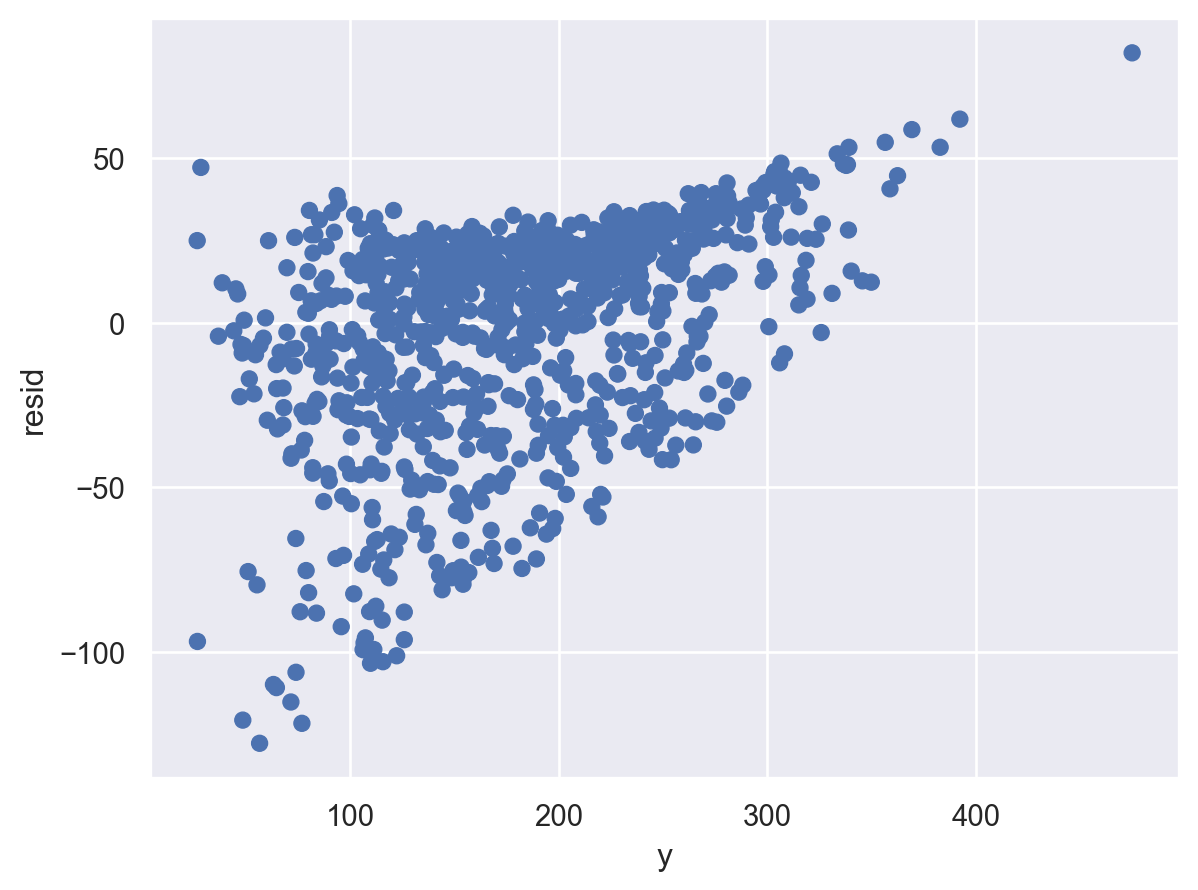

In [17]:
# Residuos en función de y
(
    so.Plot(x = df_test.y, y = df_test.resid)
    .add(so.Dot())
)

In [ ]:
# Esto nos muestra que estamos prediciendo por abajo en los valores grandes de y, pero no hay mucho que podamos hacer porque no conocemos y.

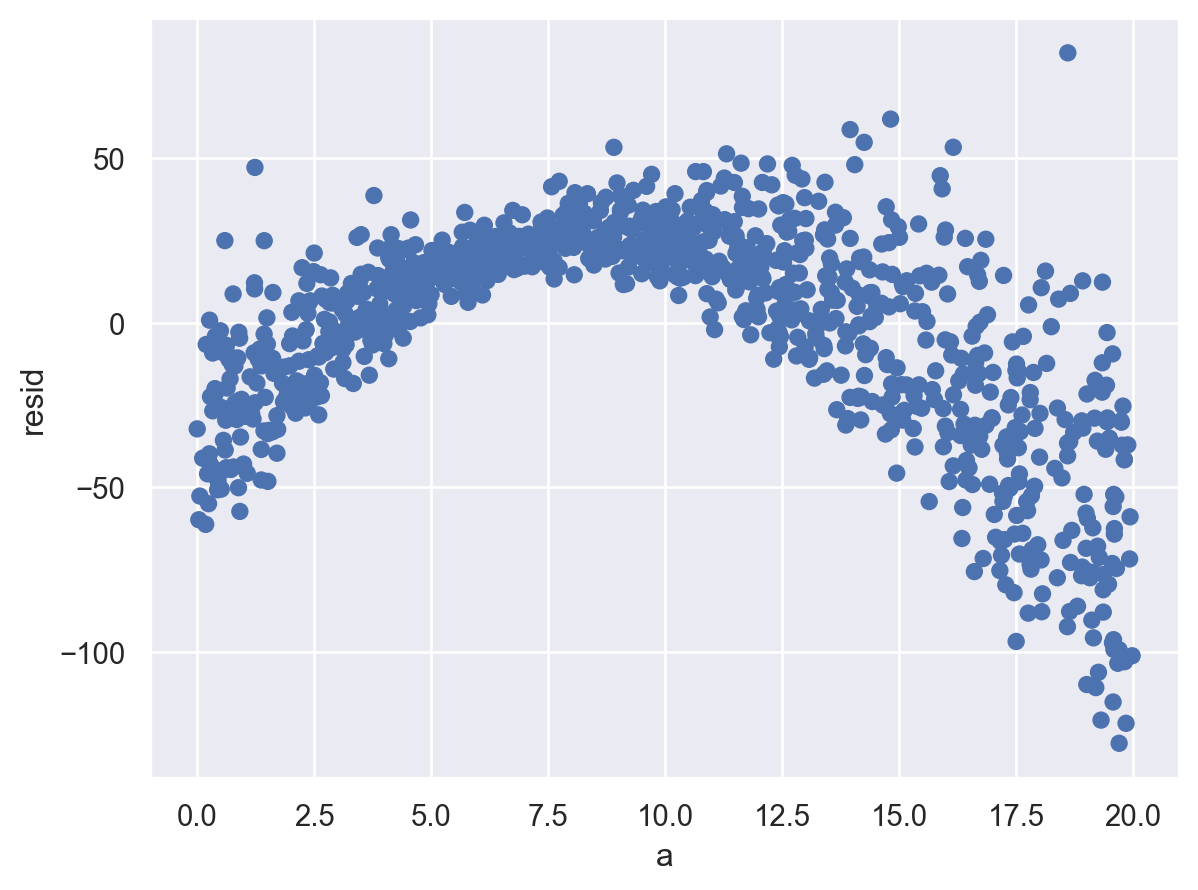

In [18]:
# Residuos en función de a
(
    so.Plot(x = df_test.a, y = df_test.resid)
    .add(so.Dot())
)

In [19]:
# Que sugiere esto?

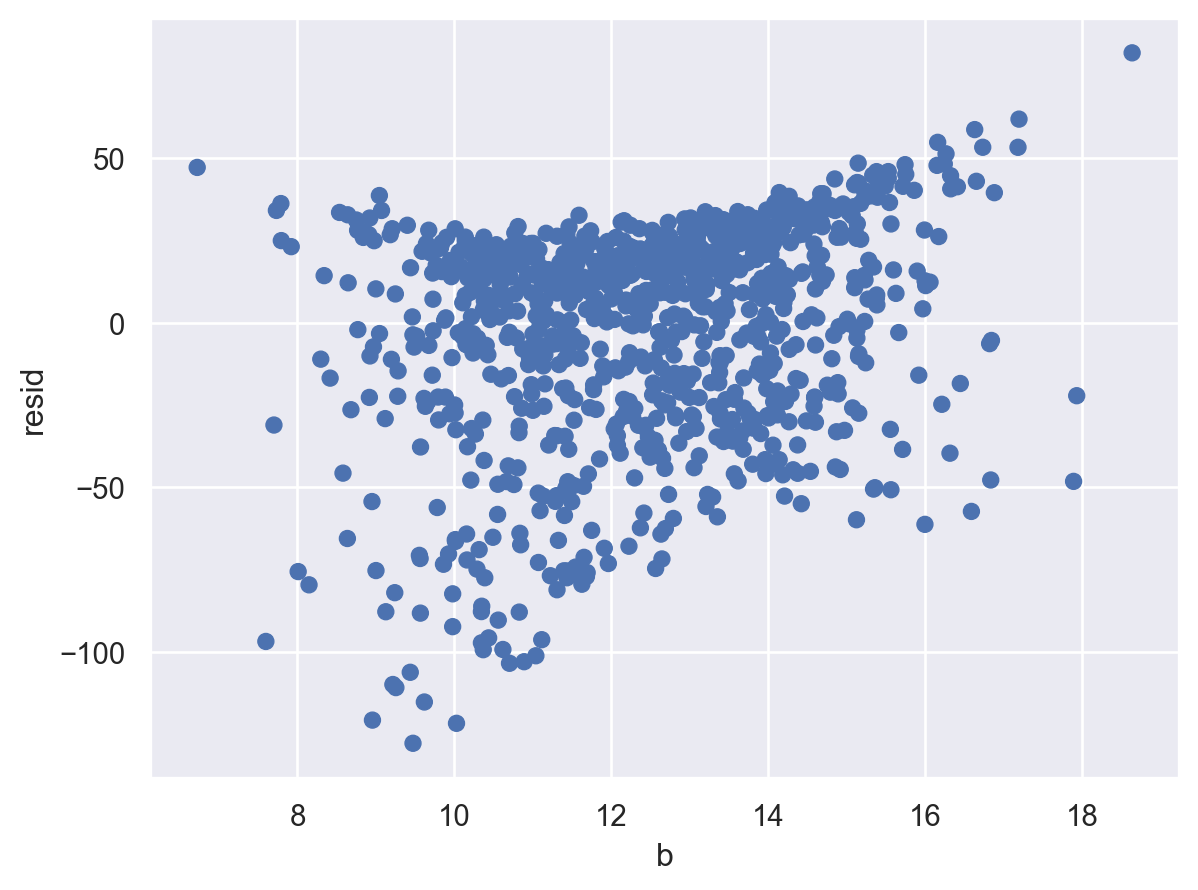

In [20]:
# Residuos en función de b
(
    so.Plot(x = df_test.b, y = df_test.resid)
    .add(so.Dot())
)

In [21]:
# No vemos mucha estructura acá, o es más dificil de saber qué hacer a partir de estos residuos.

In [22]:
# Comenzamos por agregar un término cuadrático en a.
formula = "~ poly(a, 2) + b"  # Esto aplica una normalización para evitar valores muy grandes
X_train2 = formulaic.model_matrix(formula, data= X_train)
X_train2.head()

,Intercept,"poly(a, 2)[1]","poly(a, 2)[2]",b
474,1.0,0.059976,-0.148705,11.310146
560,1.0,0.083009,-0.109338,14.764776
856,1.0,0.138758,0.022747,11.110164
747,1.0,0.078947,-0.116927,12.787338
252,1.0,-0.218963,0.080390,15.800125


In [23]:
# Ajustamos
modeloLineal2 = linear_model.LinearRegression()
modeloLineal2.fit(X_train2, y_train)

# Calculando el ECM en entrenamiento

# ECM train
y_pred2 = modeloLineal2.predict(X_train2)
ecm = mean_squared_error(y_train, y_pred2)
print('Raiz cuadarada del ECM en entrenamiento: ', np.sqrt(ecm))

Raiz cuadarada del ECM en entrenamiento:  20.46416834145256


In [24]:
# Como calculamos las predicciones? Tenemos que aplicar la misma transformación en testeo!
# La salida de formulaic no es solo la matriz, tambien guarda información de la transforamción
X_train2.model_spec

ModelSpec(formula=1 + poly(a, 2) + b, materializer='pandas', materializer_params={}, ensure_full_rank=True, na_action=<NAAction.DROP: 'drop'>, output='pandas', cluster_by=<ClusterBy.NONE: 'none'>, structure=[EncodedTermStructure(term=1, scoped_terms=[1], columns=['Intercept']), EncodedTermStructure(term=poly(a, 2), scoped_terms=[poly(a, 2)], columns=['poly(a, 2)[1]', 'poly(a, 2)[2]']), EncodedTermStructure(term=b, scoped_terms=[b], columns=['b'])], transform_state={'poly(a, 2)': {'alpha': {0: np.float64(10.332892865838806), 1: np.float64(8.04112197303255)}, 'norms2': {1: np.float64(1412.6279771668042), 0: np.float64(40.0), 2: np.float64(28418.248972950132)}}}, encoder_state={'poly(a, 2)': (<Kind.NUMERICAL: 'numerical'>, {}), 'b': (<Kind.NUMERICAL: 'numerical'>, {})})

In [25]:
ms = X_train2.model_spec

In [26]:
# Ahora podemos aplicar esas especificaciones a cualquier DataFrame! 
# En este caso seria un error aplicar la misma "fórmula", necesitamos aplicar las mismas transformaciones
X_test2 = ms.get_model_matrix(X_test)
X_test2

,Intercept,"poly(a, 2)[1]","poly(a, 2)[2]",b
521,1.0,0.198690,0.222840,13.459526
737,1.0,-0.161584,-0.073267,13.761681
740,1.0,-0.252406,0.195400,13.544226
660,1.0,-0.021450,-0.216597,14.045863
411,1.0,0.071163,-0.130696,14.005090
...,...,...,...,...
699,1.0,0.012343,-0.201910,12.936564
475,1.0,0.046434,-0.167699,15.399207
681,1.0,0.205286,0.248543,9.126229
510,1.0,-0.040606,-0.216424,13.442559


In [27]:
# Ahora si podemos calcular las predicciones en testeo

# Calculando el ECM en testeo

# ECM test
y_pred2 = modeloLineal2.predict(X_test2)
ecm = mean_squared_error(y_test, y_pred2)
print('Raiz cuadarada del ECM en testeo: ', np.sqrt(ecm))

Raiz cuadarada del ECM en testeo:  19.316831656693456


In [28]:
# Analizamos nuevamente los residuos

In [29]:
df_test2 = X_test.copy()
df_test2["y"] = y_test # No necesitamos las variables generadas
df_test2["y_pred"] = y_pred2
df_test2["resid"] = df_test2["y"] - df_test2["y_pred"]
df_test2.head()

,a,b,y,y_pred,resid
521,17.800631,13.459526,241.010740,236.784446,4.226294
737,4.259771,13.761681,174.131496,180.337736,-6.206240
740,0.846224,13.544226,110.064881,115.791001,-5.726121
660,9.526693,14.045863,250.502097,244.598875,5.903221
411,13.007541,14.005090,264.026107,258.782515,5.243592


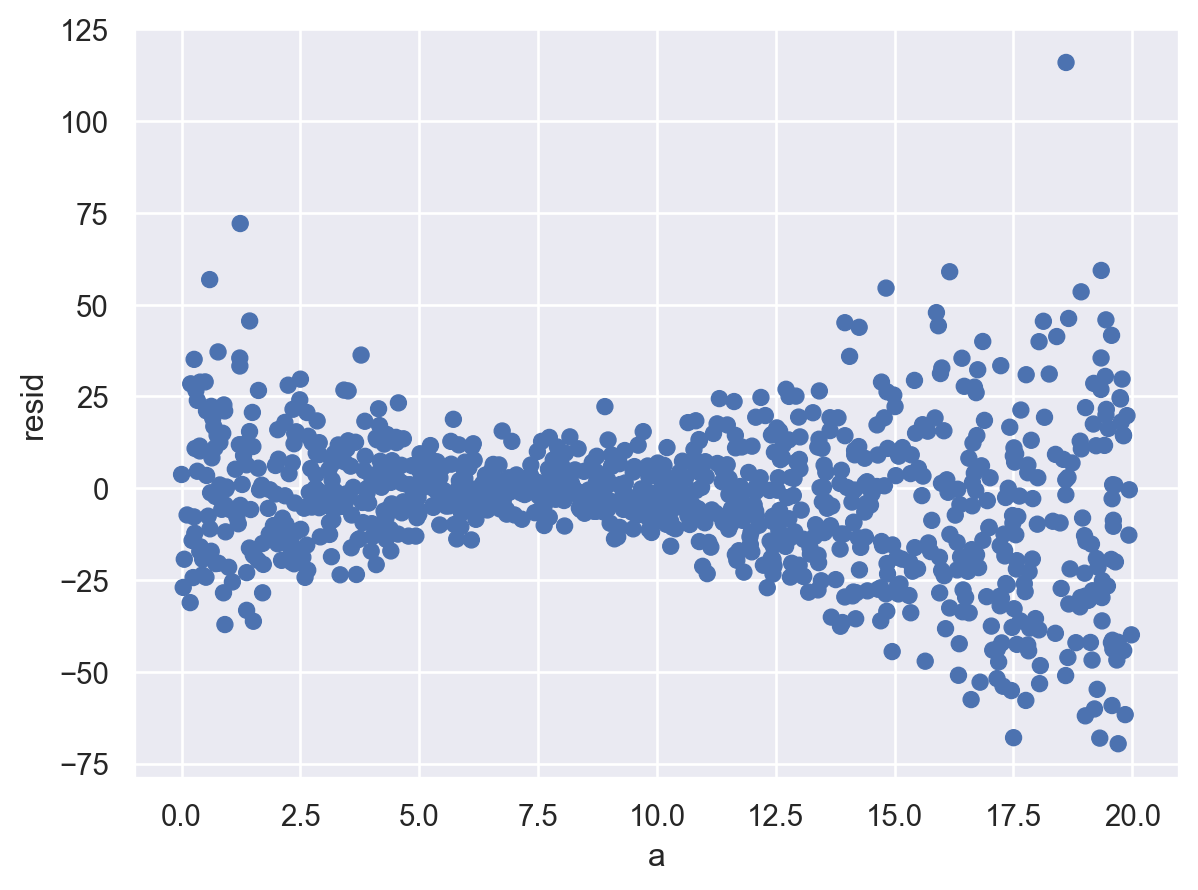

In [30]:
# Residuos en función de a
(
    so.Plot(x = df_test2.a, y = df_test2.resid)
    .add(so.Dot())
)

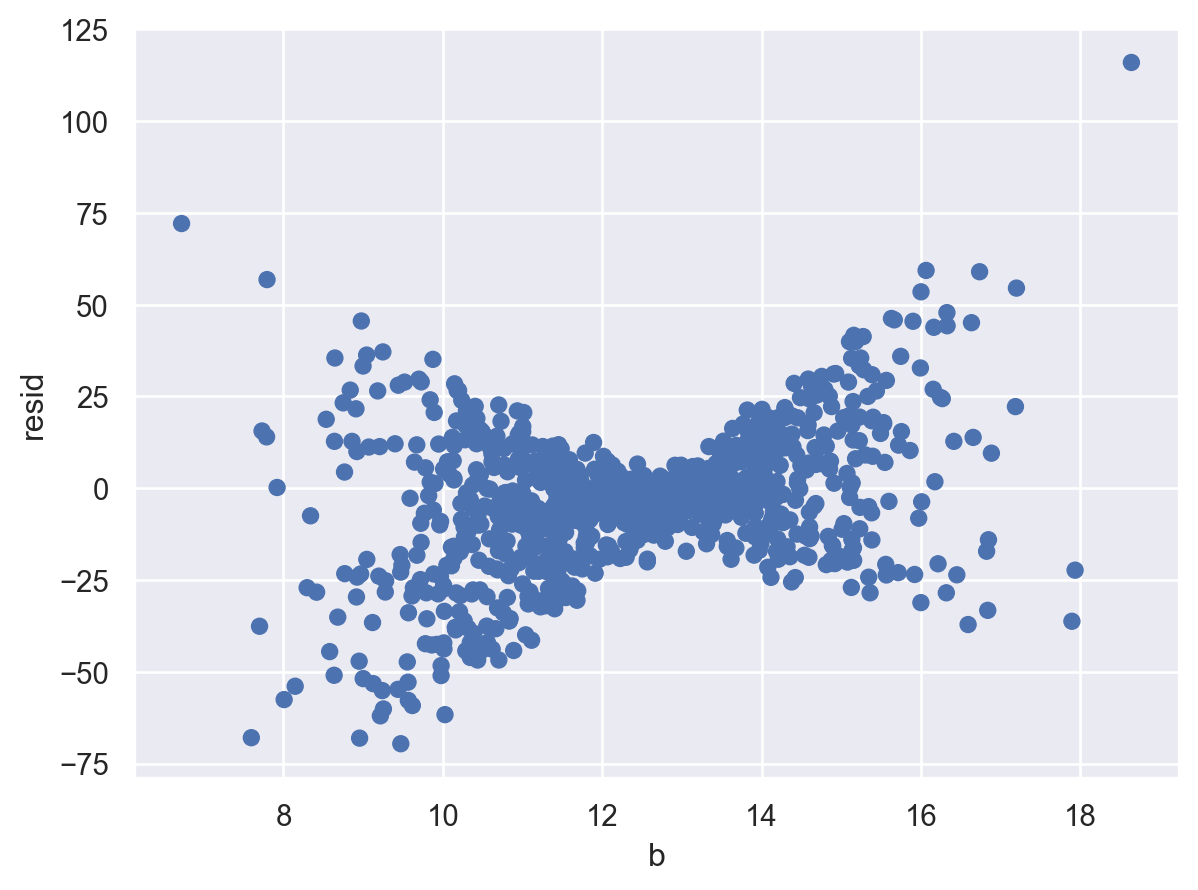

In [31]:
# Residuos en función de b
(
    so.Plot(x = df_test2.b, y = df_test2.resid)
    .add(so.Dot())
)

In [32]:
# Agregamos algunas interacciones
formula = "~ poly(a, 2) * b"  # Esto aplica una normalización para evitar valores muy grandes
X_train3 = formulaic.model_matrix(formula, data= X_train)
X_train3.head()

,Intercept,"poly(a, 2)[1]","poly(a, 2)[2]",b,"poly(a, 2)[1]:b","poly(a, 2)[2]:b"
474,1.0,0.059976,-0.148705,11.310146,0.678338,-1.681870
560,1.0,0.083009,-0.109338,14.764776,1.225608,-1.614357
856,1.0,0.138758,0.022747,11.110164,1.541620,0.252722
747,1.0,0.078947,-0.116927,12.787338,1.009518,-1.495186
252,1.0,-0.218963,0.080390,15.800125,-3.459647,1.270179


In [33]:
# Ajustamos
modeloLineal3 = linear_model.LinearRegression()
modeloLineal3.fit(X_train3, y_train)

# Calculando el ECM en entrenamiento

# ECM train
y_pred3 = modeloLineal3.predict(X_train3)
ecm = mean_squared_error(y_train, y_pred3)
print('Raiz cuadarada del ECM en entrenamiento: ', np.sqrt(ecm))

Raiz cuadarada del ECM en entrenamiento:  4.005437089993767


In [34]:
# Calculamos el ECM en testeo

ms = X_train3.model_spec

# Generamos la matriz
X_test3 = ms.get_model_matrix(X_test)
X_test3.head()

,Intercept,"poly(a, 2)[1]","poly(a, 2)[2]",b,"poly(a, 2)[1]:b","poly(a, 2)[2]:b"
521,1.0,0.198690,0.222840,13.459526,2.674268,2.999323
737,1.0,-0.161584,-0.073267,13.761681,-2.223666,-1.008274
740,1.0,-0.252406,0.195400,13.544226,-3.418645,2.646538
660,1.0,-0.021450,-0.216597,14.045863,-0.301285,-3.042297
411,1.0,0.071163,-0.130696,14.005090,0.996641,-1.830403


In [35]:
# ECM test
y_pred3 = modeloLineal3.predict(X_test3)
ecm = mean_squared_error(y_test, y_pred3)
print('Raiz cuadarada del ECM en testeo: ', np.sqrt(ecm))

Raiz cuadarada del ECM en testeo:  5.563609124905517


In [36]:
df_test3 = X_test.copy()
df_test3["y"] = y_test # No necesitamos las variables generadas
df_test3["y_pred"] = y_pred3
df_test3["resid"] = df_test3["y"] - df_test3["y_pred"]
df_test3.head()

,a,b,y,y_pred,resid
521,17.800631,13.459526,241.010740,244.856847,-3.846107
737,4.259771,13.761681,174.131496,176.422650,-2.291154
740,0.846224,13.544226,110.064881,110.744950,-0.680070
660,9.526693,14.045863,250.502097,247.176200,3.325897
411,13.007541,14.005090,264.026107,266.940285,-2.914178


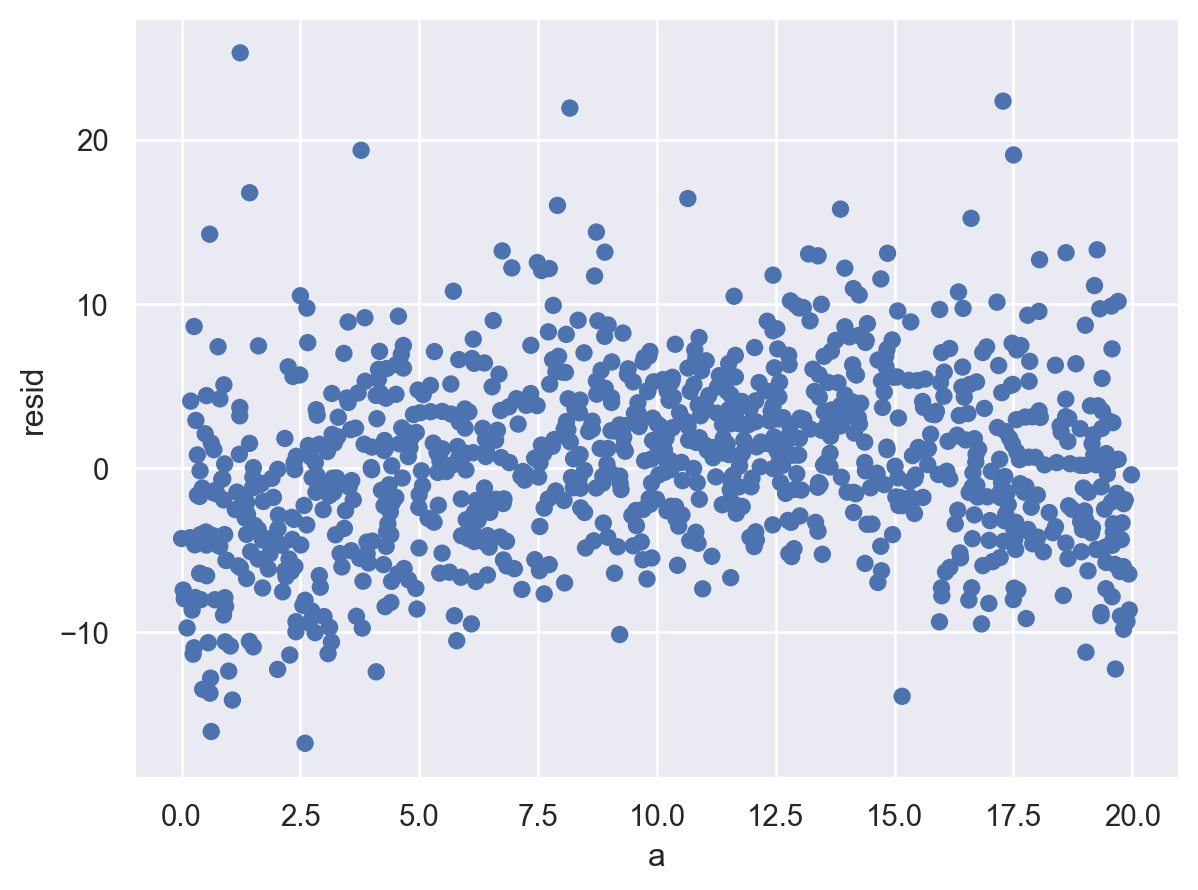

In [37]:
# Residuos en función de a
(
    so.Plot(x = df_test3.a, y = df_test3.resid)
    .add(so.Dot())
)

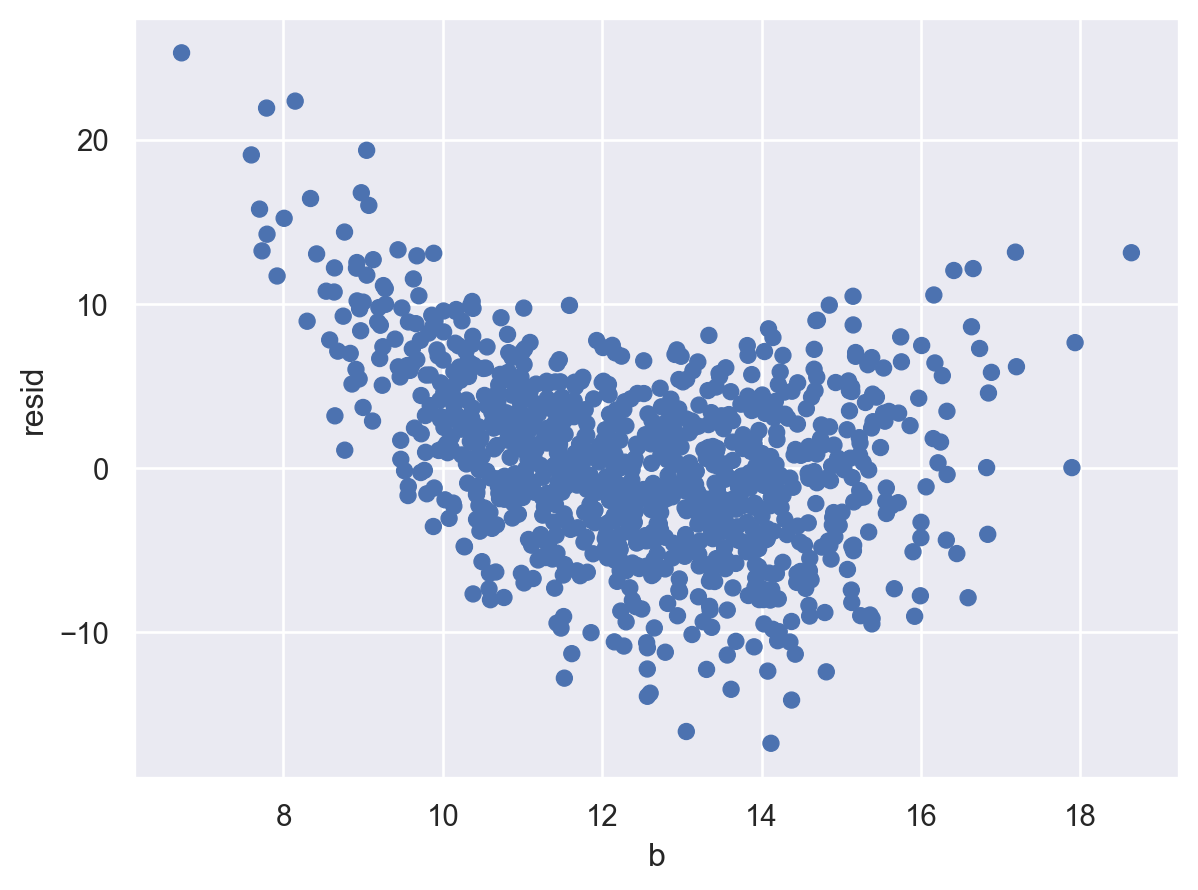

In [38]:
# Residuos en función de b
(
    so.Plot(x = df_test3.b, y = df_test3.resid)
    .add(so.Dot())
)

Podemos seguir agregando términos e interacciones de mayor grado. Vamos a hacer regresión Ridge para evitar el sobreajuste.

In [40]:
from sklearn.linear_model import Ridge

formula = "~ poly(a, 4) * poly(b, 4) - 1"
X_train4 = formulaic.model_matrix(formula, data=X_train)
ms = X_train4.model_spec
X_train4

,"poly(a, 4)[1]","poly(a, 4)[2]","poly(a, 4)[3]","poly(a, 4)[4]","poly(b, 4)[1]","poly(b, 4)[2]","poly(b, 4)[3]","poly(b, 4)[4]","poly(a, 4)[1]:poly(b, 4)[1]","poly(a, 4)[2]:poly(b, 4)[1]",...,"poly(a, 4)[3]:poly(b, 4)[2]","poly(a, 4)[4]:poly(b, 4)[2]","poly(a, 4)[1]:poly(b, 4)[3]","poly(a, 4)[2]:poly(b, 4)[3]","poly(a, 4)[3]:poly(b, 4)[3]","poly(a, 4)[4]:poly(b, 4)[3]","poly(a, 4)[1]:poly(b, 4)[4]","poly(a, 4)[2]:poly(b, 4)[4]","poly(a, 4)[3]:poly(b, 4)[4]","poly(a, 4)[4]:poly(b, 4)[4]"
474,0.059976,-0.148705,-0.127823,0.031924,-0.113806,-0.019613,0.130633,-0.082966,-0.006826,0.016923,...,0.002507,-0.000626,0.007835,-0.019426,-0.016698,0.004170,-0.004976,0.012337,0.010605,-0.002649
560,0.083009,-0.109338,-0.157026,-0.059049,0.151447,-0.056829,-0.162462,-0.026021,0.012571,-0.016559,...,0.008924,0.003356,-0.013486,0.017763,0.025511,0.009593,-0.002160,0.002845,0.004086,0.001536
856,0.138758,0.022747,-0.120068,-0.199567,-0.129161,0.002286,0.124633,-0.113047,-0.017922,-0.002938,...,-0.000275,-0.000456,0.017294,0.002835,-0.014964,-0.024873,-0.015686,-0.002571,0.013573,0.022560
747,0.078947,-0.116927,-0.153424,-0.043136,-0.000384,-0.114441,0.051318,0.119543,-0.000030,0.000045,...,0.017558,0.004937,0.004051,-0.006000,-0.007873,-0.002214,0.009437,-0.013978,-0.018341,-0.005157
252,-0.218963,0.080390,0.067665,-0.173690,0.230943,0.057605,-0.192649,-0.252822,-0.050568,0.018566,...,0.003898,-0.010005,0.042183,-0.015487,-0.013036,0.033461,0.055359,-0.020324,-0.017107,0.043912
21,-0.245650,0.170654,-0.126671,0.052901,0.313447,0.237616,-0.077973,-0.380700,-0.076998,0.053491,...,-0.030099,0.012570,0.019154,-0.013306,0.009877,-0.004125,0.093519,-0.064968,0.048224,-0.020139
313,0.165352,0.104108,-0.031746,-0.151359,-0.167449,0.066304,0.085202,-0.168177,-0.027688,-0.017433,...,-0.002105,-0.010036,0.014088,0.008870,-0.002705,-0.012896,-0.027808,-0.017509,0.005339,0.025455
459,0.154163,0.068432,-0.075375,-0.185427,0.024584,-0.119482,0.015576,0.135259,0.003790,0.001682,...,0.009006,0.022155,0.002401,0.001066,-0.001174,-0.002888,0.020852,0.009256,-0.010195,-0.025081
160,-0.062287,-0.208808,0.199132,0.161572,-0.137605,0.015250,0.119063,-0.128128,0.008571,0.028733,...,0.003037,0.002464,-0.007416,-0.024861,0.023709,0.019237,0.007981,0.026754,-0.025514,-0.020702
276,-0.259994,0.224102,-0.260391,0.257842,0.435349,0.617771,0.509696,0.324682,-0.113188,0.097563,...,-0.160862,0.159288,-0.132518,0.114224,-0.132720,0.131421,-0.084415,0.072762,-0.084544,0.083717


In [41]:
# Para definir los alfas, podemos usar np.logspace (valores espaciados en progresión geométrica)
np.logspace(0, 4, 5)

array([1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])

In [42]:
# Generamos un vector de alfas
alfas = np.logspace(-7, 1, 61)
alfas

array([1.00000000e-07, 1.35935639e-07, 1.84784980e-07, 2.51188643e-07,
       3.41454887e-07, 4.64158883e-07, 6.30957344e-07, 8.57695899e-07,
       1.16591440e-06, 1.58489319e-06, 2.15443469e-06, 2.92864456e-06,
       3.98107171e-06, 5.41169527e-06, 7.35642254e-06, 1.00000000e-05,
       1.35935639e-05, 1.84784980e-05, 2.51188643e-05, 3.41454887e-05,
       4.64158883e-05, 6.30957344e-05, 8.57695899e-05, 1.16591440e-04,
       1.58489319e-04, 2.15443469e-04, 2.92864456e-04, 3.98107171e-04,
       5.41169527e-04, 7.35642254e-04, 1.00000000e-03, 1.35935639e-03,
       1.84784980e-03, 2.51188643e-03, 3.41454887e-03, 4.64158883e-03,
       6.30957344e-03, 8.57695899e-03, 1.16591440e-02, 1.58489319e-02,
       2.15443469e-02, 2.92864456e-02, 3.98107171e-02, 5.41169527e-02,
       7.35642254e-02, 1.00000000e-01, 1.35935639e-01, 1.84784980e-01,
       2.51188643e-01, 3.41454887e-01, 4.64158883e-01, 6.30957344e-01,
       8.57695899e-01, 1.16591440e+00, 1.58489319e+00, 2.15443469e+00,
      

In [43]:
X_test4 = ms.get_model_matrix(X_test)

rmse_train = {}  # Resulta útil guardar los valores en un diccionario
rmse_test = {}
intercept = {}
for alfa in alfas:
    ridge = Ridge(alpha=alfa)
    ridge.fit(X_train4, y_train)
    rmse_train[alfa] =  np.sqrt(mean_squared_error(ridge.predict(X_train4), y_train))
    rmse_test[alfa] =  np.sqrt(mean_squared_error(ridge.predict(X_test4), y_test))
    intercept[alfa] = ridge.intercept_

In [44]:
rmse_train

{np.float64(1e-07): np.float64(2.665489561414249),
 np.float64(1.359356390878527e-07): np.float64(2.665990429116581),
 np.float64(1.8478497974222906e-07): np.float64(2.666857082077444),
 np.float64(2.5118864315095823e-07): np.float64(2.668324889647886),
 np.float64(3.414548873833601e-07): np.float64(2.670743519539923),
 np.float64(4.641588833612782e-07): np.float64(2.674593511182169),
 np.float64(6.30957344480193e-07): np.float64(2.6804669358744055),
 np.float64(8.576958985908945e-07): np.float64(2.6889835865668466),
 np.float64(1.1659144011798312e-06): np.float64(2.7006300869736073),
 np.float64(1.584893192461114e-06): np.float64(2.7155552113054515),
 np.float64(2.1544346900318822e-06): np.float64(2.73341135605813),
 np.float64(2.9286445646252375e-06): np.float64(2.753346866798113),
 np.float64(3.981071705534969e-06): np.float64(2.7741880568328456),
 np.float64(5.411695265464638e-06): np.float64(2.7947399419725754),
 np.float64(7.356422544596421e-06): np.float64(2.814072282166665),
 n

In [45]:
# Convertimos a DataFrame para graficar
data = pd.DataFrame(
    {
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "intercept": intercept,
    }
).reset_index(names="alfa")
data

,alfa,rmse_train,rmse_test,intercept
0,1.000000e-07,2.665490,76.525734,203.720887
1,1.359356e-07,2.665990,75.379457,203.585419
2,1.847850e-07,2.666857,73.890238,203.408923
3,2.511886e-07,2.668325,71.983870,203.182105
4,3.414549e-07,2.670744,69.589428,202.895669
...,...,...,...,...
56,2.928645e+00,53.112814,52.865955,192.809810
57,3.981072e+00,57.223352,56.167357,192.805018
58,5.411695e+00,60.771067,59.040484,192.797057
59,7.356423e+00,63.733876,61.453663,192.787897


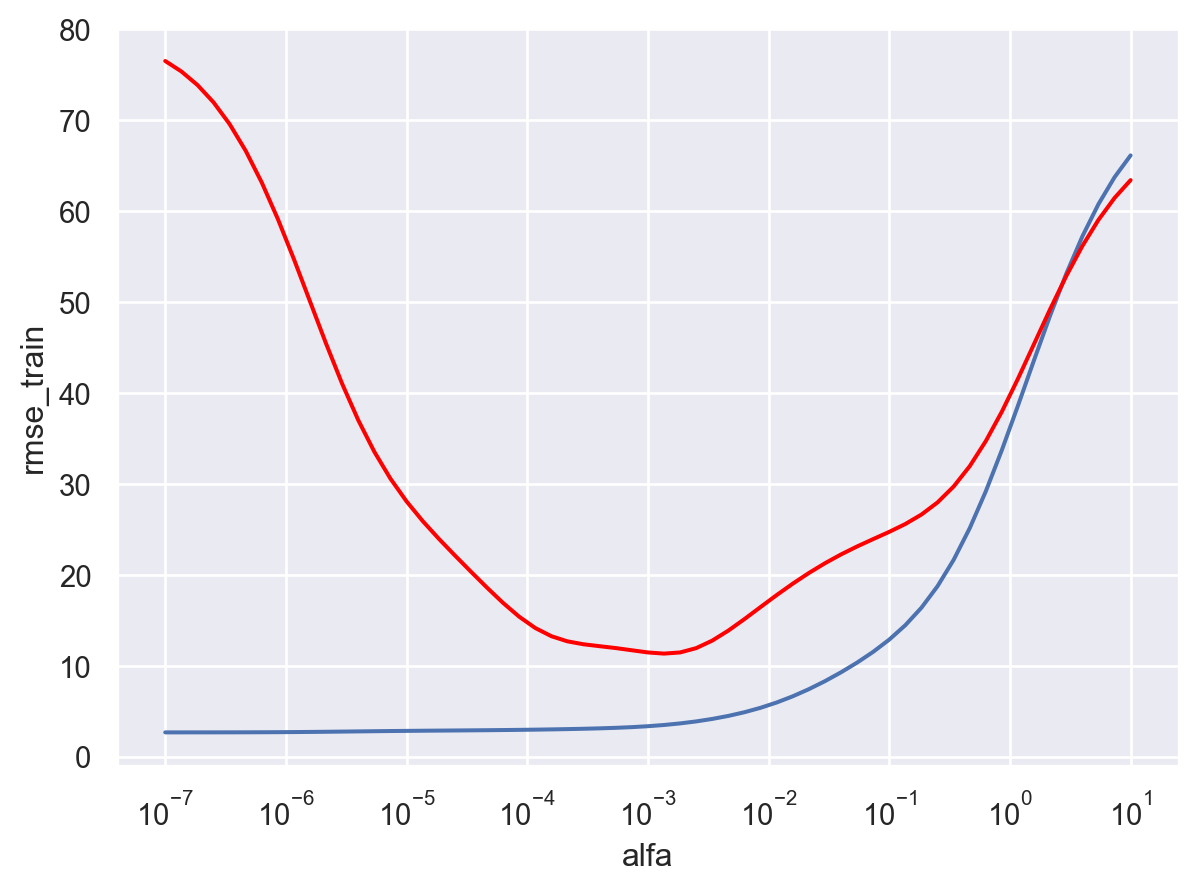

In [46]:
# Graficamos los residuos en función de alfa
(
    so.Plot(data = data, x= "alfa").scale(x = "log")
    .add(so.Line(), y = "rmse_train")
    .add(so.Line(color = "red"), y = "rmse_test")
)

In [ ]:
# Automatizamos la búsqueda con comandos de sklearn

In [ ]:
# La primera opción es usar GridSearch

In [56]:
from sklearn.model_selection import GridSearchCV

alfas = np.logspace(-7, 1, 61)

param_grid = {"alpha": alfas}
gs = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
)
gs.fit(X_train4, y_train)

gs.best_params_

{'alpha': np.float64(0.008576958985908946)}

In [57]:
# O podemos usar validacion cruzada específica de Ridge

In [58]:
modelo = linear_model.RidgeCV(
    alphas = alfas, 
    cv = 5,
    scoring="neg_root_mean_squared_error")
modelo.fit(X_train4, y_train)
modelo.alpha_

np.float64(0.008576958985908946)

In [59]:
# ECM train
y_pred = modelo.predict(X_train4)
ecm = mean_squared_error(y_train, y_pred)
print('Raiz cuadarada del ECM en entrenamiento: ', np.sqrt(ecm))

# ECM test
y_pred = modelo.predict(X_test4)
ecm = mean_squared_error(y_test, y_pred)
print('Raiz cuadarada del ECM en testeo: ', np.sqrt(ecm))

Raiz cuadarada del ECM en entrenamiento:  5.370208474904885
Raiz cuadarada del ECM en testeo:  16.454039161162598


In [60]:
# Miramos los coeficientes en forma prolija
beta1 = pd.Series(modelo.coef_, index=X_train4.columns)
beta1["intercept"] = modelo.intercept_
beta1

poly(a, 4)[1]                  255.773807
poly(a, 4)[2]                 -114.042428
poly(a, 4)[3]                   -5.546210
poly(a, 4)[4]                    9.179384
poly(b, 4)[1]                  307.085929
poly(b, 4)[2]                  -57.586166
poly(b, 4)[3]                  -84.570346
poly(b, 4)[4]                   -5.220493
poly(a, 4)[1]:poly(b, 4)[1]    289.026684
poly(a, 4)[2]:poly(b, 4)[1]     65.894346
poly(a, 4)[3]:poly(b, 4)[1]     -0.012522
poly(a, 4)[4]:poly(b, 4)[1]     70.883909
poly(a, 4)[1]:poly(b, 4)[2]    -54.462023
poly(a, 4)[2]:poly(b, 4)[2]     27.085699
poly(a, 4)[3]:poly(b, 4)[2]     26.139448
poly(a, 4)[4]:poly(b, 4)[2]     30.129461
poly(a, 4)[1]:poly(b, 4)[3]   -195.587087
poly(a, 4)[2]:poly(b, 4)[3]    -57.302400
poly(a, 4)[3]:poly(b, 4)[3]    -32.690941
poly(a, 4)[4]:poly(b, 4)[3]     15.482757
poly(a, 4)[1]:poly(b, 4)[4]    -43.500971
poly(a, 4)[2]:poly(b, 4)[4]     28.553242
poly(a, 4)[3]:poly(b, 4)[4]    -85.522247
poly(a, 4)[4]:poly(b, 4)[4]     -1

Mirando los coeficientes más grandes, ¿podemos adivinar la fórmula original?

In [61]:
# O podemos usar Leave-One-Out (es el default si no indicamos cantidad de pliegos, o podemos indicar cv = None)
# En este esquema, la cantidad de pliegos es igual a la cantidad de observaciones!
modelo = linear_model.RidgeCV(alphas = alfas)
modelo.fit(X_train4, y_train)
modelo.alpha_

np.float64(0.002511886431509582)

**Nota:** Leave-one-out parece muy lento porque a priori tenemos que ajustar tantos modelos como observaciones, pero en realidad es muy eficiente. 

Solo hay que ajustar un modelo con todos los datos y el error total puede obtenerse a partir de los elementos de la diagonal de la matriz del sistema de ecuaciones. 

In [62]:
# ECM train
y_pred = modelo.predict(X_train4)
ecm = mean_squared_error(y_train, y_pred)
print('Raiz cuadarada del ECM en entrenamiento: ', np.sqrt(ecm))

# ECM test
y_pred = modelo.predict(X_test4)
ecm = mean_squared_error(y_test, y_pred)
print('Raiz cuadarada del ECM en testeo: ', np.sqrt(ecm))

Raiz cuadarada del ECM en entrenamiento:  3.8729463833492974
Raiz cuadarada del ECM en testeo:  11.933838735755353


In [63]:
# Miramos los coeficientes en forma prolija
beta1 = pd.Series(modelo.coef_, index=X_train4.columns)
beta1["intercept"] = modelo.intercept_
beta1

poly(a, 4)[1]                  260.696330
poly(a, 4)[2]                 -118.188663
poly(a, 4)[3]                   -3.815958
poly(a, 4)[4]                    6.571960
poly(b, 4)[1]                  326.708258
poly(b, 4)[2]                  -59.696224
poly(b, 4)[3]                  -61.739252
poly(b, 4)[4]                  -18.111522
poly(a, 4)[1]:poly(b, 4)[1]    419.003985
poly(a, 4)[2]:poly(b, 4)[1]     31.051091
poly(a, 4)[3]:poly(b, 4)[1]     10.233812
poly(a, 4)[4]:poly(b, 4)[1]     73.088278
poly(a, 4)[1]:poly(b, 4)[2]   -110.574490
poly(a, 4)[2]:poly(b, 4)[2]     58.670507
poly(a, 4)[3]:poly(b, 4)[2]     34.484767
poly(a, 4)[4]:poly(b, 4)[2]     31.411608
poly(a, 4)[1]:poly(b, 4)[3]   -184.704192
poly(a, 4)[2]:poly(b, 4)[3]    -78.977876
poly(a, 4)[3]:poly(b, 4)[3]    -24.547043
poly(a, 4)[4]:poly(b, 4)[3]     25.040152
poly(a, 4)[1]:poly(b, 4)[4]    -50.752528
poly(a, 4)[2]:poly(b, 4)[4]     47.878170
poly(a, 4)[3]:poly(b, 4)[4]    -71.931629
poly(a, 4)[4]:poly(b, 4)[4]      5

## Ejercicio

Queremos predecir la edad de un paciente en función de la expresión de ciertos genes (para estudiar las causas del envejecimiento y como detenerlo).

Este es un caso típico donde tenemos muchas columnas (genes) y pocas variables (pacientes).

Usamos datos de
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE113957

En el dataset dado, realizar un modelo Ridge para ajustar la edad del paciente en función de las demás variables. 
Calcular el parámetro de suavizado por Leave-one-out.





In [ ]:
df_1000 = pd.read_csv("GSE113957_age_top1000genes.csv")
df_1000